# MDTF Variable Translation: Reusable Template

> Disclaimer: This notebook is a template for new POD notebooks and should be adapted to a specific variable or convention pair before being used as a final example. This notebook was created with GitHub Copilot assistance and is still being vetted.

This notebook shows the workflow for translating a POD variable and preprocessing data from a catalog. Its worked example uses GFDL `t_ref`, CMIP `tas`, and the `example_multicase` case-info catalog; adapt the convention, variable, and catalog settings for another POD.

Before integrating this functionality into your own notebook, update the following:
- POD convention, data convention, and requested POD variable
- required dimensions and variable metadata
- mapping and translation assertions
- any dataset paths or case metadata

For more information on variable translation, see: [variable_translation_developer_guide.ipynb](variable_translation_developer_guide.ipynb)

## 1. Notebook setup

Use this cell to locate the MDTF checkout and make imports work from either the repo root or a subdirectory.

In [24]:
import sys
from pathlib import Path

candidate_dirs = (Path.cwd(), *Path.cwd().parents)
repo_root = next(
    (path for path in candidate_dirs if (path / "src" / "translation.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Start Jupyter in the MDTF checkout or one of its subdirectories.")

sys.path.insert(0, str(repo_root))
print(f"MDTF repo root: {repo_root}")

MDTF repo root: /work5/j3k/mdtf_main/MDTF-diagnostics


## 2. Configure the example

Update the values below for a new variable pair or a new POD example.

In [25]:
POD_CONVENTION = "GFDL"
DATA_CONVENTION = "CMIP"
POD_VAR_NAME = "t_ref"

# Recommended for future reuse:
# - change these values for each new example
# - keep the rest of the notebook unchanged
#
# Example pair:
#   GFDL POD request t_ref -> CMIP data variable tas
print(f"Translate POD request {POD_CONVENTION} {POD_VAR_NAME} to {DATA_CONVENTION}")

Translate POD request GFDL t_ref to CMIP


## 3. Load fieldlists

This mirrors the framework setup path: initialize the singleton translator and read all convention tables.

In [26]:
from src.translation import VariableTranslator

translator = VariableTranslator(str(repo_root))
translator.read_conventions(str(repo_root))

print("Loaded conventions:", sorted(translator.conventions.keys()))

Loaded conventions: ['cesm', 'cmip', 'gfdl']


## 4. Validate the mapping

Before translating a full varlist entry, confirm that the POD variable's metadata identifies exactly one matching variable in the target data convention.

In [27]:
pod_field = translator.get_convention(POD_CONVENTION).lut[POD_VAR_NAME]
data_fieldlist = translator.get_convention(DATA_CONVENTION)
matched_entries = [
    (name, entry)
    for name, entry in data_fieldlist.lut.items()
    if entry.get("standard_name") == pod_field.get("standard_name")
    and entry.get("realm") == pod_field.get("realm")
    and entry.get("modifier") == pod_field.get("modifier")
    and entry.get("units") == pod_field.get("units")
]
if not matched_entries:
    raise ValueError(
        f"No matching field in {DATA_CONVENTION} for {POD_VAR_NAME} "
        f"using metadata {pod_field}"
    )
if len(matched_entries) > 1:
    raise ValueError(
        f"Multiple matches in {DATA_CONVENTION} for {POD_VAR_NAME}: "
        f"{[name for name, _ in matched_entries]}"
    )

RESOLVED_DATA_VAR = matched_entries[0][0]
data_field = data_fieldlist.lut[RESOLVED_DATA_VAR]

print("POD field:", pod_field)
print("Field metadata matches as expected.")
print("Resolved data variable:", RESOLVED_DATA_VAR)
assert pod_field["modifier"] == data_field["modifier"]
assert pod_field["realm"] == data_field["realm"]
assert pod_field["standard_name"] == data_field["standard_name"]
assert pod_field["units"] == data_field["units"]

POD field: OrderedDict({'standard_name': 'air_temperature', 'realm': 'atmos', 'long_name': 'temperature at 2 m', 'units': 'K', 'ndim': 3, 'modifier': 'atmos_height', 'alternate_standard_names': [], 'name': 't_ref'})
Field metadata matches as expected.
Resolved data variable: tas


## 5. Set up the POD, Load the Data Catalog, and Run Preprocessing (Unit Conversion and Variable Translation)

In [28]:
from types import SimpleNamespace
from src.varlist_util import Varlist

example_settings = {
    "data": {"frequency": "day", "realm": pod_field.get("realm") or "atmos"},
    "dimensions": {
        "lat": {
            "axis": "Y",
            "standard_name": "latitude",
            "units": "degrees_north",
        },
        "lon": {
            "axis": "X",
            "standard_name": "longitude",
            "units": "degrees_east",
        },
        "time": {"axis": "T", "standard_name": "time", "units": "days"},
    },
    "varlist": {
        POD_VAR_NAME: {
            "standard_name": pod_field["standard_name"],
            "long_name": pod_field.get("long_name", ""),
            "units": pod_field["units"],
            "modifier": pod_field.get("modifier", ""),
            "dimensions": ["time", "lat", "lon"],
        }
    },
}

pod = SimpleNamespace(
    name="translation_template",
    pod_data=example_settings["data"],
    pod_dims=example_settings["dimensions"],
    pod_vars=example_settings["varlist"],
    pod_settings={"convention": POD_CONVENTION},
    _log_name="translation_template",
)

requested_var = Varlist.from_struct(pod).vars[0]

translated_var = translator.translate(
    requested_var,
    to_convention=DATA_CONVENTION,
    from_convention=POD_CONVENTION,
)
requested_var.translation = translated_var

print("POD request:", requested_var.convention, requested_var.name, requested_var.standard_name)
print("Translated data variable:", translated_var.name, translated_var.standard_name)
assert translated_var.name == RESOLVED_DATA_VAR
assert requested_var.translation.name == translated_var.name

POD request: GFDL t_ref air_temperature
Translated data variable: tas air_temperature


### Load catalog data and run framework preprocessing

Read CMIP `tas` from the catalog referenced by `case_info_demo2.yml`. For each configured case, apply `ConvertUnitsFunction` and `RenameVariablesFunction` to the dataset. The converted datasets remain lazy and open in `preprocessed_datasets` for downstream use.

In [29]:
from pathlib import Path

import intake
import yaml

from src.preprocessor import ConvertUnitsFunction, RenameVariablesFunction

example_dir = repo_root / "diagnostics" / "example_multicase"
case_info_path = example_dir / "case_info_demo2.yml"
with case_info_path.open() as stream:
    case_info = yaml.safe_load(stream)

# Resolve the catalog path from case info, falling back to its colocated copy.
catalog_path = Path(case_info["CATALOG_FILE"]).expanduser()
if not catalog_path.is_file():
    catalog_path = example_dir / catalog_path.name
if not catalog_path.is_file():
    raise FileNotFoundError(f"Case-info catalog not found: {catalog_path}")

catalog = intake.open_esm_datastore(str(catalog_path))
variable_catalog = catalog.search(
    variable_id=translated_var.name,
    frequency="daily",
)
if variable_catalog.df.empty:
    raise ValueError(f"No daily catalog entries found for {translated_var.name}")

source_datasets = {}
preprocessed_datasets = {}
for case_key, case_config in case_info["CASE_LIST"].items():
    case_name = case_config["case_name"]
    experiment_ids = [
        experiment_id
        for experiment_id in variable_catalog.df["experiment_id"].dropna().unique()
        if str(experiment_id) in case_name
    ]
    if len(experiment_ids) != 1:
        raise ValueError(
            f"Expected one catalog experiment for {case_name!r}; "
            f"found {experiment_ids}"
        )

    case_catalog = catalog.search(
        variable_id=translated_var.name,
        frequency="daily",
        experiment_id=experiment_ids[0],
    )
    case_datasets = case_catalog.to_dataset_dict(
        xarray_open_kwargs={"decode_times": True, "use_cftime": True}
    )
    if len(case_datasets) != 1:
        raise ValueError(
            f"Expected one daily dataset for {case_name!r}; "
            f"found {len(case_datasets)}"
        )

    source_dataset, = case_datasets.values() # Take the first value. Only one is expected.
    source_datasets[case_key] = source_dataset

    pod_dataset = ConvertUnitsFunction().execute(
        requested_var, source_dataset.copy(deep=False)
    )
    pod_dataset = RenameVariablesFunction().execute(requested_var, pod_dataset)
    if translated_var.name != requested_var.name:
        pod_dataset = pod_dataset.rename_vars(
            {translated_var.name: requested_var.name}
        )

    assert requested_var.name in pod_dataset.data_vars
    preprocessed_datasets[case_key] = pod_dataset
    print(
        f"{case_name}: {DATA_CONVENTION} {translated_var.name} -> "
        f"{POD_CONVENTION} {requested_var.name}; "
        f"sizes={dict(pod_dataset.sizes)}"
    )


--> The keys in the returned dictionary of datasets are constructed as follows:
	'experiment_id.frequency.modeling_realm.variable_id'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCo

c384L65_am5f3b1r0_amip: CMIP tas -> GFDL t_ref; sizes={'time': 1096, 'lat': 720, 'lon': 1152, 'bnds': 2}

--> The keys in the returned dictionary of datasets are constructed as follows:
	'experiment_id.frequency.modeling_realm.variable_id'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/work/Janice.Kim/mdtf_main/conda_env_main/_MDTF_base/lib/python3.12/site-packages/intake_esm/source.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCo

amip_c96L65_am5f3b1r0_pdclim1850F: CMIP tas -> GFDL t_ref; sizes={'time': 3650, 'lat': 180, 'lon': 288, 'bnds': 2}


## 6. Use `preprocessed_datasets` for Diagnostic Calculations and Plotting

> Disclaimer: This template example follows the developer-guide demonstration: calculate each case's time-mean `t_ref`, shuffle its spatial values for a visually varied example, then calculate the global-mean anomaly and zonal mean. Shuffling destroys the geographic pattern, so the plotted profiles are for demonstration only and are not scientific results.

Calculated illustrative shuffled zonal-mean anomaly for c384L65_am5f3b1r0_amip
Calculated illustrative shuffled zonal-mean anomaly for amip_c96L65_am5f3b1r0_pdclim1850F


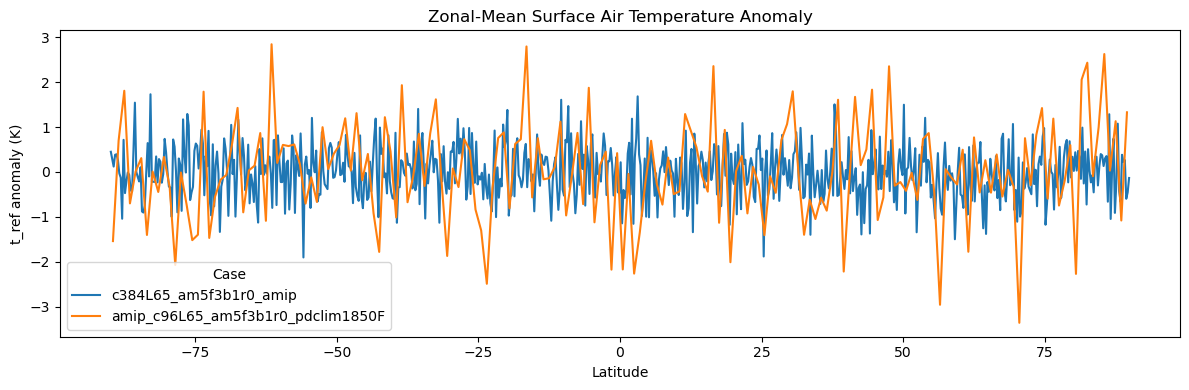

In [31]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

case_config = next(iter(case_info["CASE_LIST"].values()))
time_coord = case_config["time_coord"]
lon_coord = case_config["lon_coord"]

np.random.seed(0)
zonal_mean_anomalies = {}
for case_key, dataset in preprocessed_datasets.items():
    time_mean = dataset[requested_var.name].mean(dim=time_coord).load()
    shuffled_values = time_mean.to_masked_array().flatten()
    np.random.shuffle(shuffled_values)
    time_mean.values = shuffled_values.reshape(time_mean.shape)

    anomaly = time_mean - time_mean.mean()
    zonal_mean_anomalies[case_key] = anomaly.mean(dim=lon_coord)
    print(f"Calculated illustrative shuffled zonal-mean anomaly for {case_key}")

for dataset in source_datasets.values():
    dataset.close()
catalog.close()

fig, ax = plt.subplots(figsize=(12, 4))
for case_key, latitude_profile in zonal_mean_anomalies.items():
    latitude_profile.plot(ax=ax, label=case_key)

ax.set_title("Zonal-Mean Surface Air Temperature Anomaly")
ax.set_xlabel("Latitude")
ax.set_ylabel(f"{requested_var.name} anomaly ({requested_var.units})")
ax.legend(title="Case")
plt.tight_layout()
plt.show()